# Lab 4

In this lab, you will implement functions to train neural networks to predict the specie of a raising. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings 
warnings.filterwarnings('ignore')

In [2]:
epochs_num = 500
train = pd.read_csv("Raisin_train.csv")
test = pd.read_csv("Raisin_test.csv")

classes = train['Class'].unique()
mapping = {cls: i for i, cls in enumerate(classes)}
print("Mapping:", mapping)
train['Class'] = train['Class'].map(mapping)
test['Class'] = test['Class'].map(mapping)
train

Mapping: {'Besni': 0, 'Kecimen': 1}


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,101439,524.817186,251.160554,0.878051,107520,0.733312,1393.213,0
1,117592,533.292856,288.558319,0.840966,123587,0.730068,1432.006,0
2,51180,288.631065,226.630491,0.619254,52396,0.737443,855.997,1
3,59589,383.571233,201.381855,0.851091,62974,0.684082,1043.187,1
4,105091,507.685116,268.087343,0.849208,108296,0.700271,1295.591,0
...,...,...,...,...,...,...,...,...
795,129038,540.814829,306.817764,0.823494,134796,0.648758,1459.345,0
796,105347,476.803500,282.025816,0.806310,108072,0.769035,1266.876,0
797,118787,562.280957,273.329909,0.873898,125083,0.643713,1459.584,0
798,83932,499.237754,224.472389,0.893215,88572,0.670844,1258.062,0


In [3]:
# Standar normalization
# x_norm = x - u / σ 

def standar_norm(X):
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_norm = (X - X_mean) / X_std
    return X_norm

In [4]:
columns = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']
X = train[columns]
y = train[['Class']]

X_test = test[columns]
y_test = test[['Class']]

X = standar_norm(X)
X_test = standar_norm(X_test)
print(np.unique(y))
X

[0 1]


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
0,0.333605,0.798856,-0.079275,1.053420,0.385660,0.641447,0.818128
1,0.748067,0.872470,0.663835,0.643671,0.780444,0.580037,0.960416
2,-0.955965,-1.252490,-0.566698,-1.806031,-0.968798,0.719652,-1.152306
3,-0.740203,-0.427907,-1.068400,0.755543,-0.708885,-0.290505,-0.465719
4,0.427310,0.650059,0.257068,0.734738,0.404727,0.015958,0.460064
...,...,...,...,...,...,...,...
795,1.041754,0.937800,1.026658,0.450622,1.055862,-0.959205,1.060691
796,0.433878,0.381843,0.534031,0.260760,0.399223,1.317710,0.354742
797,0.778729,1.124240,0.361240,1.007538,0.817203,-1.054707,1.061568
798,-0.115598,0.576691,-0.609581,1.220968,-0.079913,-0.541103,0.322413


Use part of the training set as validation set

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
264,-0.594873,-0.120216,-0.981480,0.976861,-0.543620,-0.627982,-0.347551
615,-1.073456,-1.350441,-0.772525,-1.730775,-1.065584,1.177975,-1.283949
329,-0.971617,-1.055215,-0.930577,-0.436759,-0.984843,0.405791,-1.087091
342,-1.341741,-1.320873,-1.759659,0.245496,-1.337242,2.136095,-1.551501
394,-0.814100,-1.210997,-0.147708,-2.726844,-0.827588,1.492834,-0.974374
...,...,...,...,...,...,...,...
71,0.118151,0.327667,-0.017672,0.649054,0.081863,-1.268938,0.168517
106,-1.215886,-1.007473,-1.745058,0.734359,-1.200528,-1.102555,-1.185918
270,-0.336338,-0.595884,0.212946,-1.096057,-0.350957,0.447751,-0.346128
435,-1.041382,-0.952661,-1.262552,0.248984,-1.047647,1.397261,-1.136149


Built a function that trains a neural network using the training set and that stop at a predefined number of epochs.

In [6]:
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [7]:
def binary_cross_entropy(y_pred, y_true):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [8]:
def neural_network(X_train, 
            y_train, 
            num_hidden_layers, 
            output_size,
            number_neural_by_layer, 
            num_epochs, 
            learning_rate, 
            activation_funcs,
            activation_derivs
):
    
    if hasattr(y_train, 'values'):
        y_train = y_train.values.reshape(-1, 1)
    else:
        y_train = y_train.reshape(-1, 1)
    input_size = X_train.shape[1]

    if (len(number_neural_by_layer) != num_hidden_layers):
        print("ERROR!!! Number of neurons per layer is not equal to number of hidder layers")
        return
    
    if len(activation_funcs) != (num_hidden_layers + 1):
        print("Activation funcs must be one per layer (hidden + output)")
        return
    
    if len(activation_derivs) != (num_hidden_layers + 1):
        print("Activation derivatives must be one per layer (hidden + output)")
        return 

    layer_sizes = [input_size] + number_neural_by_layer + [output_size]
    
    weight = []
    bias = []
    for i in range(len(layer_sizes)-1):
        w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
        b = np.zeros((1, layer_sizes[i + 1]))
        weight.append(w)
        bias.append(b)

    loss = []
    for epoch in range(num_epochs):
        # Forward pass
        #z[0] = x1*w1 + x2*w2 + ... + x7*w7 + b
        A = X_train
        activations = [A]
        z_values = []
        for i in range(len(layer_sizes)-1):
            z = np.dot(A, weight[i]) + bias[i]
            z_values.append(z)
            A = activation_funcs[i](z)
            activations.append(A)

        y_pred = A
        l = binary_cross_entropy(y_pred, y_train)
        loss.append(l)

        # Print progress
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {l:.6f}")
        
        # Backward pass
        deltas = []
        gradient_loss_respect_actprev = (y_pred - y_train) # Gradient of the loss function with respect to the previous activation
        #gradient_loss_respect_actprev = (y_pred - y_train) * activation_derivs[-1](z_values[-1])  
        deltas.append(gradient_loss_respect_actprev)
        #print(gradient_loss_respect_actprev.shape) # -> shape of D datapoints x 1 neurons

        ## Gradient of the loss function with respect to the weights and biases
        for i in range(len(layer_sizes) - 2, -0, -1):
            delta = np.dot(deltas[0], weight[i].T) * activation_derivs[i-1](z_values[i-1])
            deltas.insert(0, delta)
        
        ## Update weights and biases with gradient descent
        for i in range(len(layer_sizes)-1):
            weight[i] -= learning_rate * np.dot(activations[i].T, deltas[i])
            bias[i] -= learning_rate * np.sum(deltas[i], axis=0, keepdims=True)

    return weight, bias, loss

Built a function that predicts using the trained neural network.

In [9]:
#Get probabilities
def predict(X, weights, biases, functionActivation=sigmoid):
    A = X
    for i in range(len(weights)):
        z = np.dot(A, weights[i]) + biases[i]
        A = functionActivation(z)
    return A

#Get binary labels
def predict_labels(X, weight, bias, threshold=1, functionActivation=sigmoid):
    probabilities = predict(X, weight, bias, functionActivation)
    return (probabilities >= threshold).astype(int)


Build a function that outputs the points you need to plot the ROC curve given a set of true labels and the correspondant predictions.

In [10]:
def compute_roc_curve(y_true, y_pred_proba, num_thresholds=100):
    list_thresholds = np.linspace(0, 1, num_thresholds)  
    tpr_list = []
    fpr_list = []
    
    for thresh in list_thresholds:
        y_pred = (y_pred_proba >= thresh).astype(float)
        
        y_true_np = np.array(y_true).flatten()
        y_pred_np = np.array(y_pred).flatten()
        
        TP = np.sum((y_true_np == 1) & (y_pred_np == 1))
        TN = np.sum((y_true_np == 0) & (y_pred_np == 0))
        FP = np.sum((y_true_np == 0) & (y_pred_np == 1))
        FN = np.sum((y_true_np == 1) & (y_pred_np == 0))
        
        TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) != 0 else 0
        
        tpr_list.append(TPR)
        fpr_list.append(FPR)
    
    return fpr_list, tpr_list, list_thresholds

In [11]:
def array_activation_funcs(functionActivation, num_hidden_layers):
    return [functionActivation] * num_hidden_layers + [sigmoid]

def array_activation_derivs(functionActivationDerivs, num_hidden_layers):
    return [functionActivationDerivs] * num_hidden_layers + [sigmoid_derivative]

attemp_num_hidden_layers = 2

weight, bias, loss = neural_network(
    X_train=X_train,
    y_train=y_train, 
    num_hidden_layers=attemp_num_hidden_layers, 
    output_size = 1,
    number_neural_by_layer=[8, 4],
    num_epochs=epochs_num,
    learning_rate=0.01,
    ### you can put other activation function relu, tanh
    activation_funcs=array_activation_funcs(sigmoid, attemp_num_hidden_layers),
    activation_derivs=array_activation_derivs(sigmoid_derivative, attemp_num_hidden_layers)
)
y_pred_proba = predict(X_test, weight, bias)

fpr, tpr, thresholds = compute_roc_curve(y_test.values, y_pred_proba)

Epoch 0, Loss: 0.693213
Epoch 100, Loss: 0.368635
Epoch 200, Loss: 0.366828
Epoch 300, Loss: 0.365362


Epoch 400, Loss: 0.363568


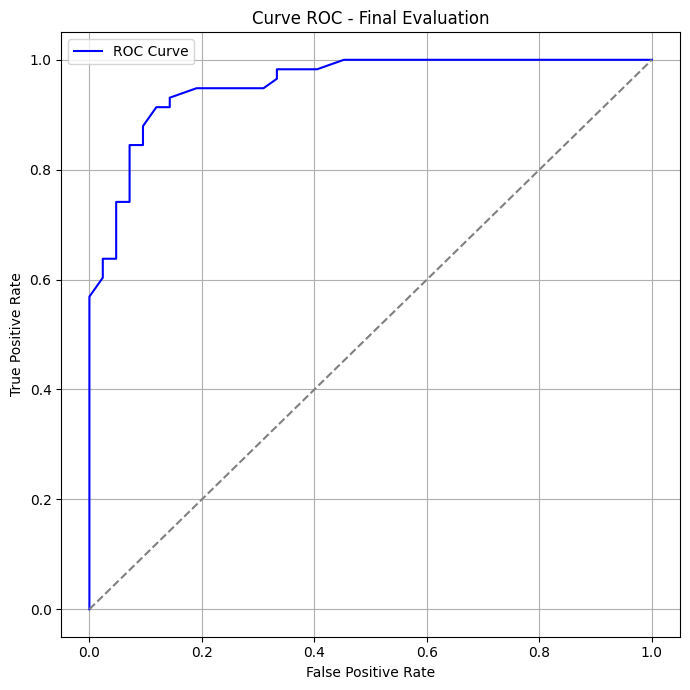

In [12]:
def plot_roc_curve(fpr, tpr):
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, label=f"ROC Curve", color="blue")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curve ROC - Final Evaluation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_roc_curve(fpr, tpr)

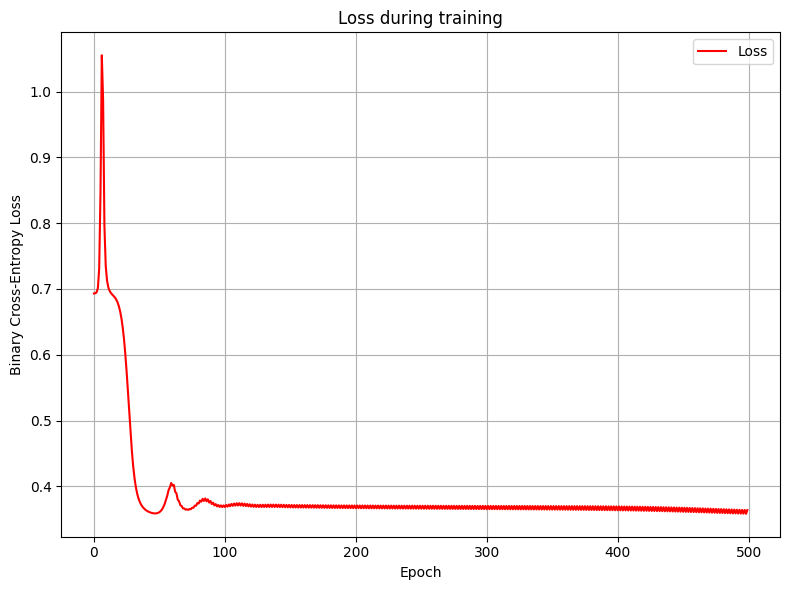

In [13]:
def plot_loss(loss, title="Loss during training"):
    plt.figure(figsize=(8, 6))
    plt.plot(loss, label='Loss', color='red')
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_loss(loss)

Built a function that compute the area under the ROC curve using the points your last function outputs.

In [14]:
def compute_auc(fpr, tpr):
    #sort values ​​for more security
    sorted_indices = np.argsort(fpr)
    fpr_sorted = np.array(fpr)[sorted_indices]
    tpr_sorted = np.array(tpr)[sorted_indices]
    return np.trapz(tpr_sorted, fpr_sorted)

Select your hyperparameters by evaluating a number of models in the validation set

In [15]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
hidden_structures = [[6,4,2], [6,4,2,2], [8, 4], [5,3,5,3,2], [7,6,5,4,3,2], [4, 4, 2], [7, 7, 7]]

best_auc = 0
best_params = None

for lr in learning_rates:
    for layers in hidden_structures:
        print(f"\nTesting lr={lr}, layers={layers}")
        num_hidden_layers = len(layers)

        # Build activation functions and derivatives, num layers + 1 output
        # Also you can use other activation functions, change sigmoid to relu or tanh
        activation_funcs = [sigmoid] * num_hidden_layers + [sigmoid]
        activation_derivs = [sigmoid_derivative] * num_hidden_layers + [sigmoid_derivative]

        weights, biases, loss = neural_network(
            X_train=X_train,
            y_train=y_train, 
            num_hidden_layers=num_hidden_layers,
            output_size=1,
            number_neural_by_layer=layers,
            num_epochs=epochs_num, 
            learning_rate=lr,
            activation_funcs=activation_funcs,
            activation_derivs=activation_derivs
        )
        y_pred_val = predict(X_val, weights, biases)
        fpr, tpr, thresholds = compute_roc_curve(y_val, y_pred_val, 10)
        auc_score = compute_auc(fpr, tpr)

        if auc_score > best_auc:
            best_auc = auc_score
            best_params = (lr, layers)



Testing lr=0.1, layers=[6, 4, 2]
Epoch 0, Loss: 0.693148
Epoch 100, Loss: 2.894726
Epoch 200, Loss: 2.894734
Epoch 300, Loss: 2.894734
Epoch 400, Loss: 2.894734

Testing lr=0.1, layers=[6, 4, 2, 2]
Epoch 0, Loss: 0.693142
Epoch 100, Loss: 8.190015
Epoch 200, Loss: 3.387403
Epoch 300, Loss: 2.894748
Epoch 400, Loss: 2.894734

Testing lr=0.1, layers=[8, 4]
Epoch 0, Loss: 0.693143
Epoch 100, Loss: 0.853747
Epoch 200, Loss: 2.378986
Epoch 300, Loss: 1.346664
Epoch 400, Loss: 1.644033

Testing lr=0.1, layers=[5, 3, 5, 3, 2]
Epoch 0, Loss: 0.693146
Epoch 100, Loss: 2.894730
Epoch 200, Loss: 2.894734
Epoch 300, Loss: 2.894734
Epoch 400, Loss: 2.894734

Testing lr=0.1, layers=[7, 6, 5, 4, 3, 2]
Epoch 0, Loss: 0.693142
Epoch 100, Loss: 7.101114
Epoch 200, Loss: 2.971200
Epoch 300, Loss: 2.894735
Epoch 400, Loss: 2.894734

Testing lr=0.1, layers=[4, 4, 2]
Epoch 0, Loss: 0.693143
Epoch 100, Loss: 2.908134
Epoch 200, Loss: 2.894714
Epoch 300, Loss: 2.894683
Epoch 400, Loss: 2.894373

Testing lr=0

In [16]:
best_auc

np.float64(0.957034340876721)

In [17]:
best_params

(0.01, [8, 4])

Add your validation set to the training set, train your final neural network model. Assess you final model using the test set. Plot the ROC curve and include the auroc.

In [18]:
X_final_train = np.vstack([X_train, X_val])
y_final_train = np.concatenate([y_train, y_val])

lr, layers = best_params
activation_funcs = [sigmoid] * len(layers) + [sigmoid]
activation_derivs = [sigmoid_derivative] * len(layers) + [sigmoid_derivative]

final_weights, final_biases, final_loss = neural_network(
    X_train=X_final_train,
    y_train=y_final_train,
    num_hidden_layers=len(layers),
    number_neural_by_layer=layers,
    output_size=1,
    num_epochs=epochs_num,
    learning_rate=lr,
    activation_funcs=array_activation_funcs(sigmoid, len(layers)),
    activation_derivs=array_activation_derivs(sigmoid_derivative, len(layers))
)

y_test_pred_proba = predict(X_test, final_weights, final_biases)
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)
fpr_final, tpr_final, thresholds_final = compute_roc_curve(y_test.values, y_test_pred_proba, num_thresholds=100)
auc_score_final = compute_auc(fpr_final, tpr_final)

print(f"AUC final about test: {auc_score_final:.4f}")

Epoch 0, Loss: 0.693121
Epoch 100, Loss: 0.339084
Epoch 200, Loss: 0.338305
Epoch 300, Loss: 0.333045
Epoch 400, Loss: 0.326029
AUC final about test: 0.9565


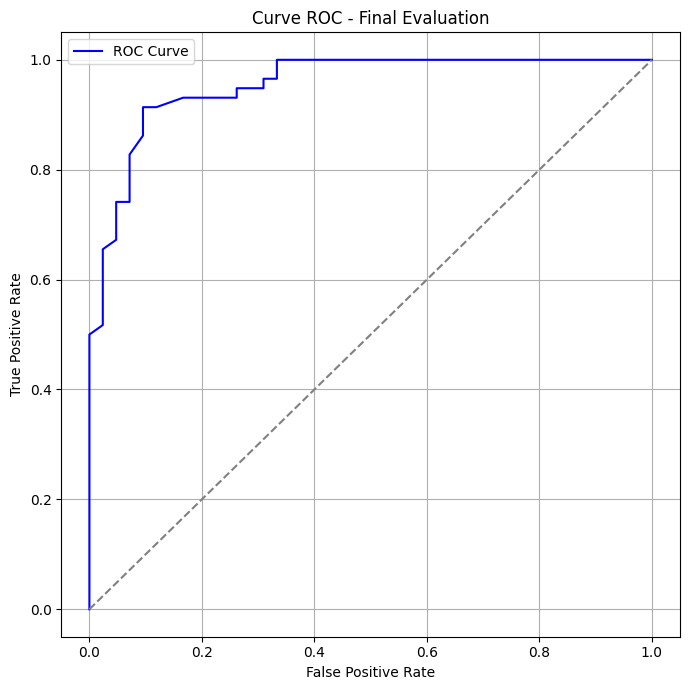

In [19]:
plot_roc_curve(fpr_final, tpr_final)

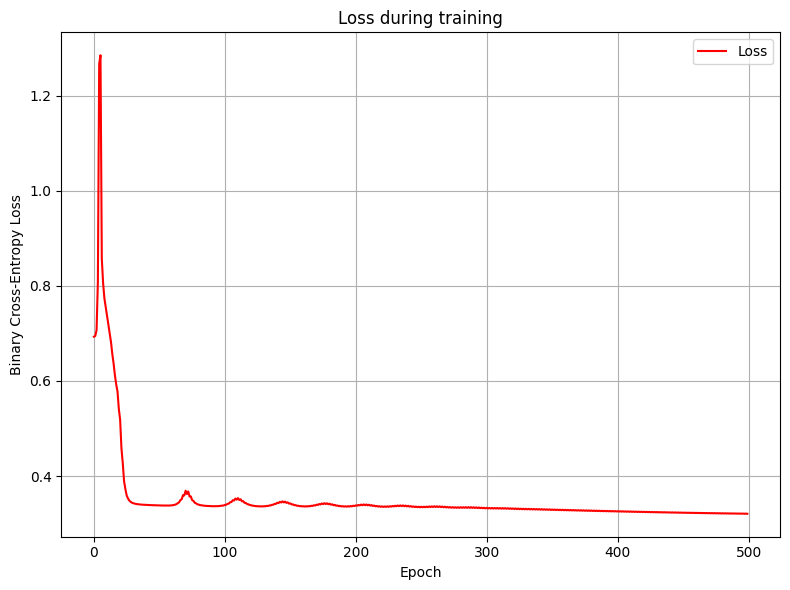

In [20]:
plot_loss(final_loss)